# Appendix 2 Technical Appendix for Layered Semantic Cartography

This two-file appendix reproduces the figures and empirical results reported in the revised manuscript and supplies the methodological details requested during review. Keep `Appendix_2.ipynb` and `Appendix_2_Dataset.parquet` in the same folder. The first code cell installs any missing Python packages in the active Jupyter kernel.

## 1. Data and analytical specifications

In [1]:
# Install only packages that are not already available.
# Existing scientific packages are deliberately left untouched because replacing
# NumPy or pandas inside a running kernel can create binary incompatibilities.
from importlib.util import find_spec
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "pyarrow": "pyarrow",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
    "statsmodels": "statsmodels",
    "sklearn": "scikit-learn",
    "umap": "umap-learn",
    "ollama": "ollama",
}

packages_to_install = [
    package_name
    for import_name, package_name in REQUIRED_PACKAGES.items()
    if find_spec(import_name) is None
]

if packages_to_install:
    print("Installing missing packages:", ", ".join(packages_to_install))
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            *packages_to_install,
        ]
    )
    print("Installation complete. Restart the kernel, then run all cells.")
else:
    print("All required Python packages are available; no changes were made.")

All required Python packages are available; no changes were made.


In [2]:
from pathlib import Path
import json
import re
import urllib.request
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns

from IPython.display import Markdown, display
from matplotlib.colors import SymLogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=RuntimeWarning, module=r"sklearn\.utils\.extmath")
warnings.filterwarnings("ignore", message=r"n_jobs value 1 overridden.*")

DATA_FILE = Path("Appendix_2_Dataset.parquet")

# Optional: set this to a direct GitHub release-asset or raw-file URL. If the
# local dataset is absent, the notebook will download it automatically.
DATA_URL = None

# The submitted notebook displays the saved repeated-run results. Set this to
# True to repeat the six local LLM runs using Ollama.
RERUN_LLM_STABILITY = False

if not DATA_FILE.exists():
    if DATA_URL is None:
        raise FileNotFoundError(
            "Appendix_2_Dataset.parquet must be beside this notebook, or DATA_URL "
            "must be set to its direct GitHub download URL."
        )
    urllib.request.urlretrieve(DATA_URL, DATA_FILE)

TOPIC_ID = 6
RANDOM_SEED = 42
MCPLANT_ANNOUNCEMENT = pd.Timestamp("2020-11-09")

In [3]:
parquet_table = pq.read_table(DATA_FILE)
parquet_metadata = parquet_table.schema.metadata or {}
df = parquet_table.to_pandas()

df["created_utc"] = pd.to_datetime(df["created_utc"], errors="coerce")
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df["sentiment_value"] = pd.to_numeric(df["sentiment_value"], errors="coerce")
df["umap2_x"] = pd.to_numeric(df["umap2_x"], errors="raise").astype("float64")
df["umap2_y"] = pd.to_numeric(df["umap2_y"], errors="raise").astype("float64")
df["year"] = df["created_utc"].dt.year

# Older pandas/Anaconda combinations can recurse inside the optional Bottleneck
# reduction path. The analyses below use NumPy explicitly for coordinate reductions.
pd.set_option("compute.use_bottleneck", False)

df["brand_layer"] = np.select(
    [
        df["Beyond"].gt(0) & df["Impossible"].eq(0),
        df["Impossible"].gt(0) & df["Beyond"].eq(0),
        df["Beyond"].gt(0) & df["Impossible"].gt(0),
    ],
    ["Beyond Meat", "Impossible Foods", "Both"],
    default="Other",
)

corpus_summary = pd.DataFrame({
    "measure": ["observations", "start date", "end date", "Topic 6 observations"],
    "value": [
        len(df),
        df["created_utc"].min().date(),
        df["created_utc"].max().date(),
        int(df["bertopic_topic"].eq(TOPIC_ID).sum()),
    ],
})
display(corpus_summary)

,measure,value
0,observations,279896
1,start date,2010-01-28
2,end date,2023-09-30
3,Topic 6 observations,4930


In [4]:
MODEL_SETTINGS = [
    ("Embedding", "sentence-transformers/all-distilroberta-v1; raw body text; 768 dimensions"),
    ("Map UMAP", "n_components=2; n_neighbors=30; min_dist=0.05; metric=cosine; random_state=42; low_memory=True"),
    ("BERTopic UMAP", "n_components=5; n_neighbors=15; min_dist=0.0; metric=cosine; original run used the default unseeded state"),
    ("HDBSCAN", "min_cluster_size=300; min_samples=50; metric=euclidean; cluster_selection_method=eom; prediction_data=True"),
    ("BERTopic vectorizer", "stop_words=english; min_df=20; max_df=0.9"),
    ("Sentiment", "cardiffnlp/twitter-roberta-base-sentiment-latest; max_length=512; negative=-1, neutral=0, positive=1"),
    ("Reported LLM interpretation", "llama3.1:8b; temperature=0.1; num_predict=900; 100 posts closest to the Topic 6 centroid"),
]

settings = pd.DataFrame(MODEL_SETTINGS, columns=["stage", "specification"])
display(settings)

,stage,specification
0,Embedding,sentence-transformers/all-distilroberta-v1; ra...
1,Map UMAP,n_components=2; n_neighbors=30; min_dist=0.05;...
2,BERTopic UMAP,n_components=5; n_neighbors=15; min_dist=0.0; ...
3,HDBSCAN,min_cluster_size=300; min_samples=50; metric=e...
4,BERTopic vectorizer,stop_words=english; min_df=20; max_df=0.9
5,Sentiment,cardiffnlp/twitter-roberta-base-sentiment-late...
6,Reported LLM interpretation,llama3.1:8b; temperature=0.1; num_predict=900;...


**Variables.** Brand layers use the supplied `Beyond` and `Impossible` indicators. Engagement is the original Reddit `score`; negative scores are retained and neither percentile bands nor engagement labels are used in the statistical analysis. Sentiment is the saved numerical `sentiment_value` rather than the categorical sentiment label.

**MapsLSC and the manuscript figures.** The manuscript figures use the full corpus. The public MapsLSC demonstration uses a random 3,000-observation subset for interactive demonstration and is not a processing ceiling. Processing time, cost, and maximum corpus size depend on the selected models, the corpus, and the available hardware.

## 2. Manuscript figures

### Figure 1. Base semantic map

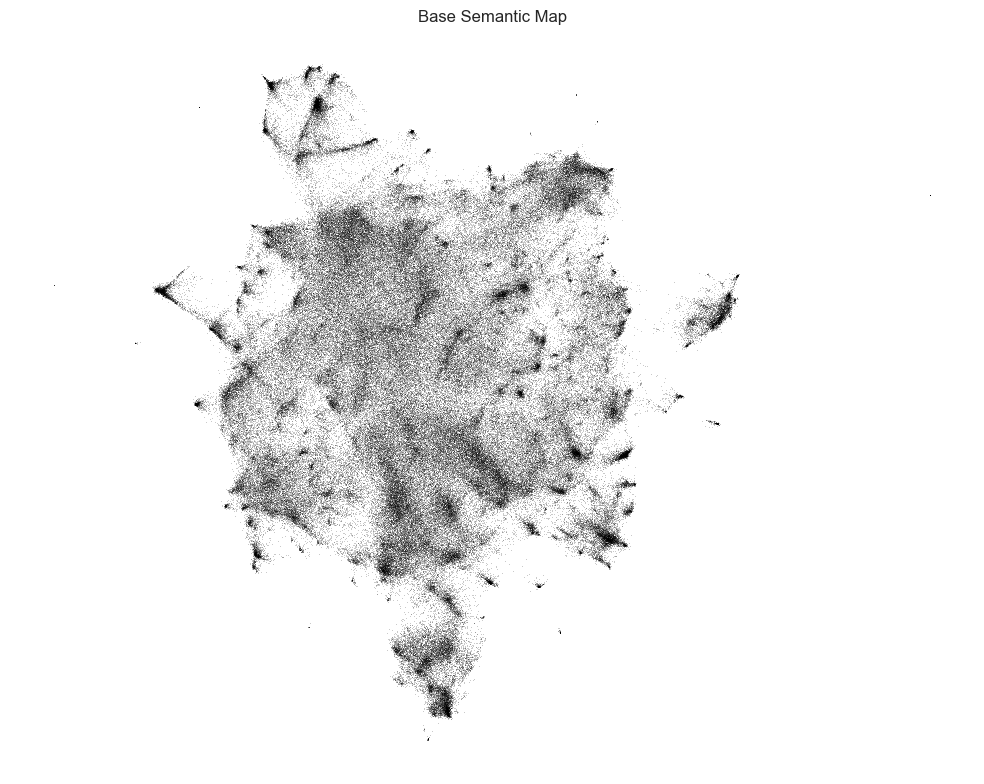

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(
    df["umap2_x"], df["umap2_y"],
    s=0.4, c="black", alpha=0.18, linewidths=0, rasterized=True,
)
ax.set_title("Base Semantic Map")
ax.axis("off")
fig.tight_layout()
plt.show()

### Figure 2. Brand and topic layers

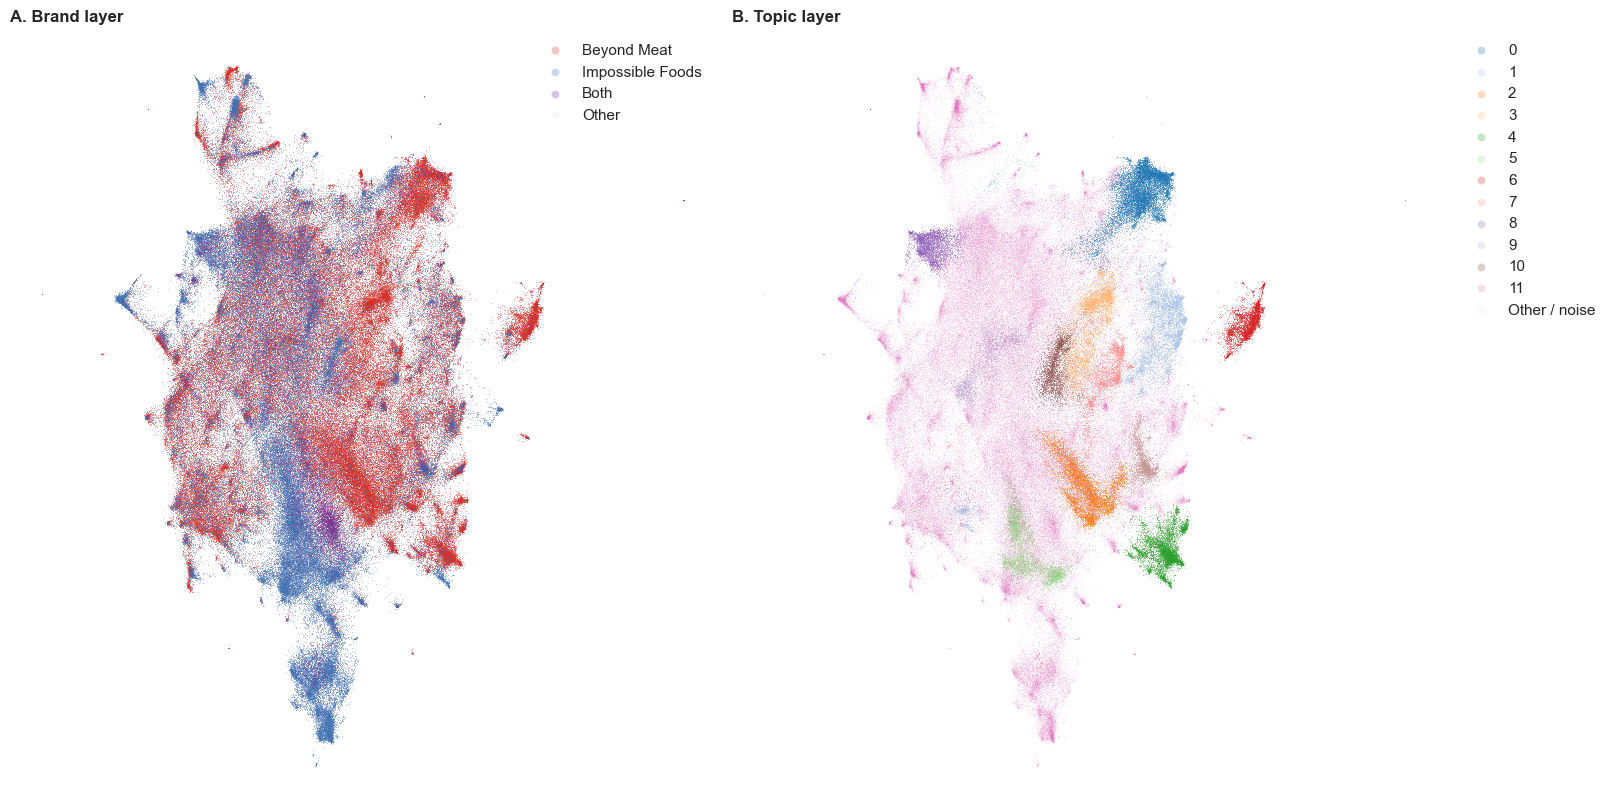

In [6]:
brand_colors = {
    "Beyond Meat": "#d73027",
    "Impossible Foods": "#4575b4",
    "Both": "#7b3294",
    "Other": "#bdbdbd",
}

top_topics = (
    df.loc[df["bertopic_topic"].ne(-1), "bertopic_topic"]
    .value_counts().head(12).index
)
df["topic_layer"] = np.where(
    df["bertopic_topic"].isin(top_topics),
    df["bertopic_topic"].astype(str),
    "Other / noise",
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)

for label, color in brand_colors.items():
    sub = df[df["brand_layer"].eq(label)]
    axes[0].scatter(
        sub["umap2_x"], sub["umap2_y"], s=0.5, c=color,
        alpha=0.28 if label != "Other" else 0.08,
        linewidths=0, rasterized=True, label=label,
    )
axes[0].set_title("A. Brand layer", loc="left", fontweight="bold")
axes[0].axis("off")
axes[0].legend(markerscale=8, frameon=False)

topic_levels = [str(topic) for topic in top_topics] + ["Other / noise"]
topic_colors = dict(zip(topic_levels, sns.color_palette("tab20", len(topic_levels))))
for label in topic_levels:
    sub = df[df["topic_layer"].eq(label)]
    axes[1].scatter(
        sub["umap2_x"], sub["umap2_y"], s=0.5,
        c=[topic_colors[label]],
        alpha=0.28 if label != "Other / noise" else 0.06,
        linewidths=0, rasterized=True, label=label,
    )
axes[1].set_title("B. Topic layer", loc="left", fontweight="bold")
axes[1].axis("off")
axes[1].legend(markerscale=8, frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.show()

### Figure 3. Topic 6 layers

In [7]:
topic6 = df[df["bertopic_topic"].eq(TOPIC_ID)].copy()

def numeric_array(series):
    return np.fromiter(
        (float(value) for value in series.tolist()),
        dtype=np.float64,
        count=len(series),
    )

topic6_x = numeric_array(topic6["umap2_x"])
topic6_y = numeric_array(topic6["umap2_y"])
centroid = np.array([np.nanmean(topic6_x), np.nanmean(topic6_y)])
topic6["distance_to_centroid"] = np.sqrt(
    (topic6_x - centroid[0]) ** 2
    + (topic6_y - centroid[1]) ** 2
)

topic6["era"] = pd.cut(
    topic6["created_utc"],
    bins=[pd.Timestamp.min, MCPLANT_ANNOUNCEMENT, pd.Timestamp("2022-01-01"), pd.Timestamp.max],
    labels=["pre-announcement", "announcement through 2021", "2022 onward"],
    right=False,
)

topic6_text = topic6["body"].fillna("").astype(str)
topic6["literal_mcplant"] = topic6_text.str.contains(r"\bmcplant\b", case=False, regex=True)
topic6["mcplant_product_reference"] = (
    topic6["literal_mcplant"]
    & topic6["created_utc"].ge(MCPLANT_ANNOUNCEMENT)
)

top_subreddits = topic6["subreddit"].value_counts().head(6).index
topic6["subreddit_layer"] = np.where(
    topic6["subreddit"].isin(top_subreddits), topic6["subreddit"], "Other"
)

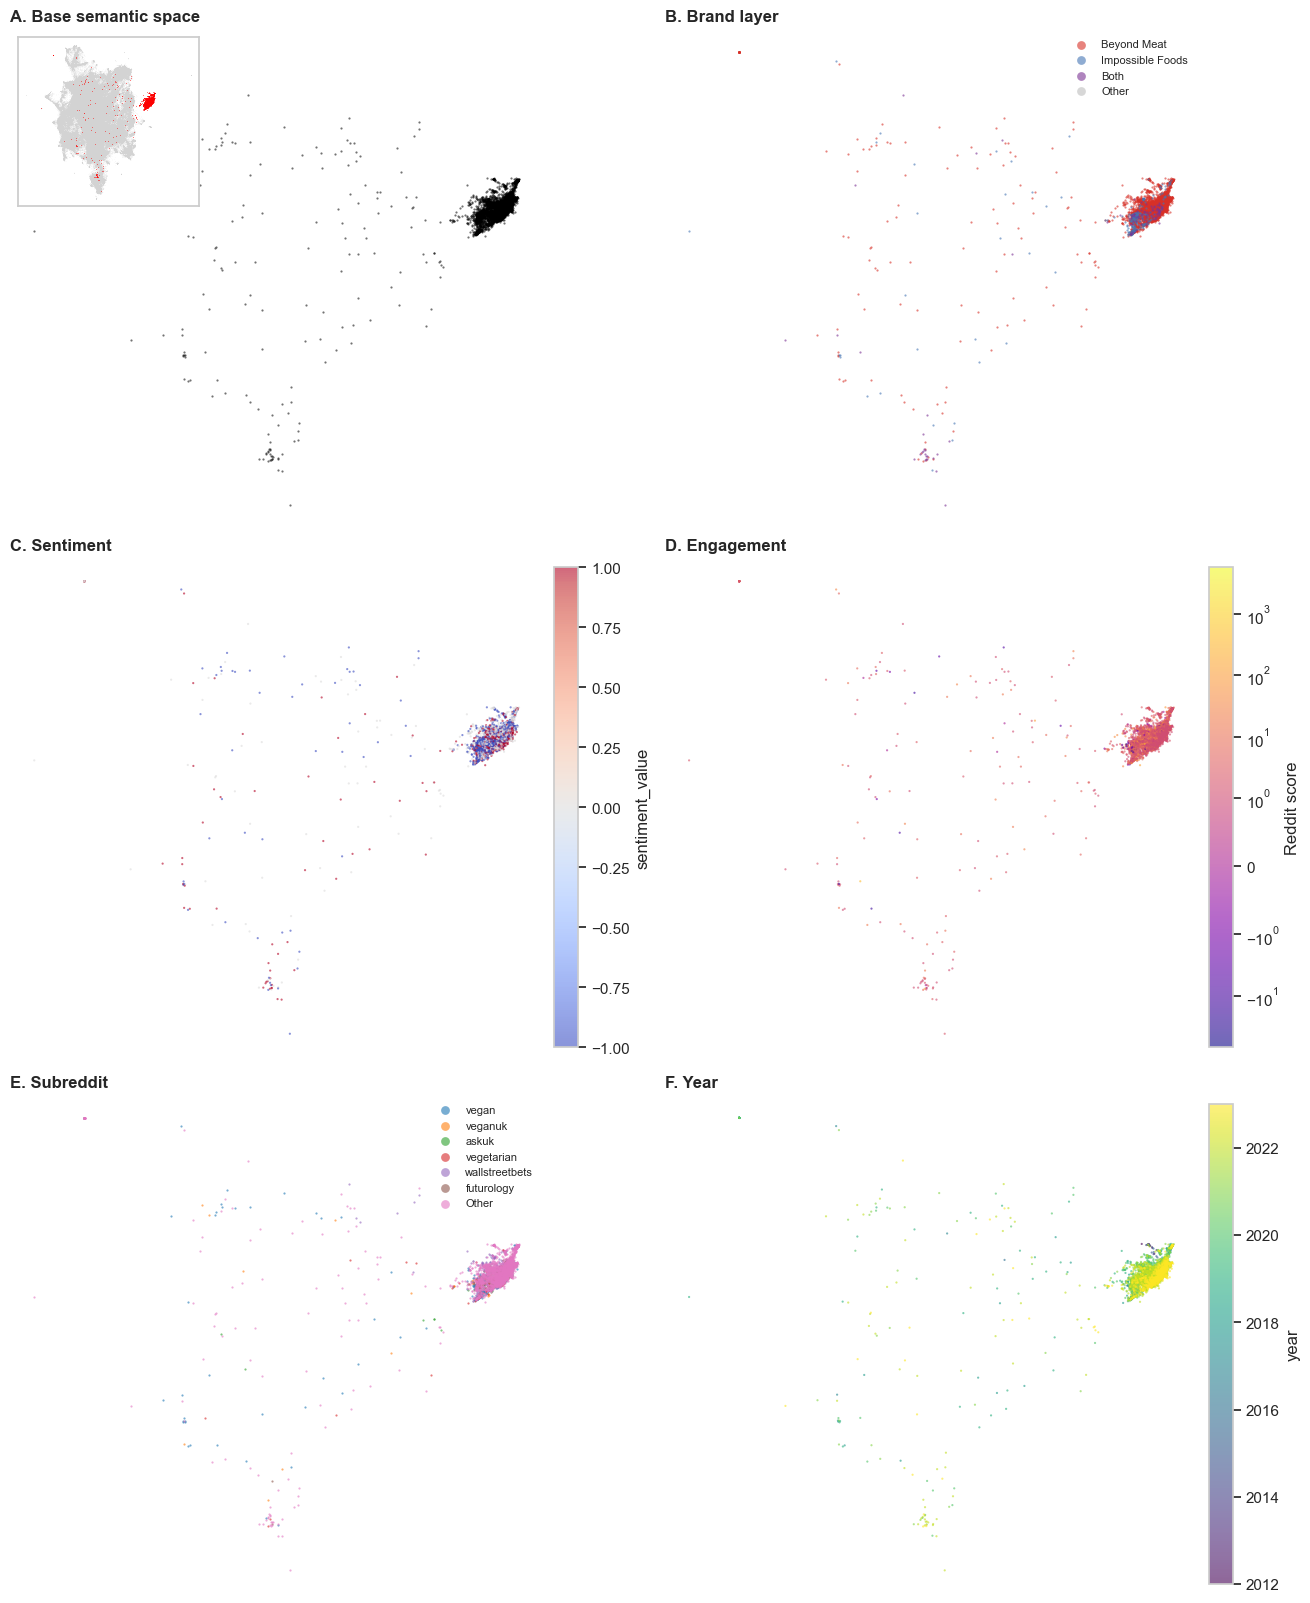

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(13, 16), constrained_layout=True)
axes = axes.ravel()

def clean_map_axis(ax, title):
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

# A. Base Topic 6 geometry with full-corpus locator.
axes[0].scatter(
    topic6["umap2_x"], topic6["umap2_y"],
    s=2.5, c="black", alpha=0.55, linewidths=0, rasterized=True,
)
clean_map_axis(axes[0], "A. Base semantic space")
mini = inset_axes(axes[0], width="34%", height="34%", loc="upper left")
mini.scatter(df["umap2_x"], df["umap2_y"], s=0.12, c="lightgrey", alpha=0.18, linewidths=0, rasterized=True)
mini.scatter(topic6["umap2_x"], topic6["umap2_y"], s=0.35, c="red", alpha=0.55, linewidths=0, rasterized=True)
mini.set_xticks([])
mini.set_yticks([])

# B. Brand layer.
for label, color in brand_colors.items():
    sub = topic6[topic6["brand_layer"].eq(label)]
    axes[1].scatter(sub["umap2_x"], sub["umap2_y"], s=2.5, c=color, alpha=0.60, linewidths=0, label=label)
clean_map_axis(axes[1], "B. Brand layer")
axes[1].legend(frameon=False, fontsize=8, markerscale=4)

# C. Numerical sentiment.
sentiment_scatter = axes[2].scatter(
    topic6["umap2_x"], topic6["umap2_y"], s=2.5,
    c=topic6["sentiment_value"], cmap="coolwarm", vmin=-1, vmax=1,
    alpha=0.60, linewidths=0,
)
clean_map_axis(axes[2], "C. Sentiment")
fig.colorbar(sentiment_scatter, ax=axes[2], fraction=0.045, pad=0.02, label="sentiment_value")

# D. Raw Reddit score.
score_scatter = axes[3].scatter(
    topic6["umap2_x"], topic6["umap2_y"], s=2.5,
    c=topic6["score"], cmap="plasma",
    norm=SymLogNorm(
        linthresh=1,
        vmin=topic6["score"].min(),
        vmax=topic6["score"].max(),
    ),
    alpha=0.60, linewidths=0,
)
clean_map_axis(axes[3], "D. Engagement")
fig.colorbar(score_scatter, ax=axes[3], fraction=0.045, pad=0.02, label="Reddit score")

# E. Subreddit layer.
subreddit_levels = list(top_subreddits) + ["Other"]
subreddit_colors = dict(zip(subreddit_levels, sns.color_palette("tab10", len(subreddit_levels))))
for label in subreddit_levels:
    sub = topic6[topic6["subreddit_layer"].eq(label)]
    axes[4].scatter(sub["umap2_x"], sub["umap2_y"], s=2.5, c=[subreddit_colors[label]], alpha=0.60, linewidths=0, label=label)
clean_map_axis(axes[4], "E. Subreddit")
axes[4].legend(frameon=False, fontsize=8, markerscale=4)

# F. Time layer.
year_scatter = axes[5].scatter(
    topic6["umap2_x"], topic6["umap2_y"], s=2.5,
    c=topic6["year"], cmap="viridis", alpha=0.60, linewidths=0,
)
clean_map_axis(axes[5], "F. Year")
fig.colorbar(year_scatter, ax=axes[5], fraction=0.045, pad=0.02, label="year")

plt.show()

### Figure 4. Topic 6 sentiment over time by subreddit group

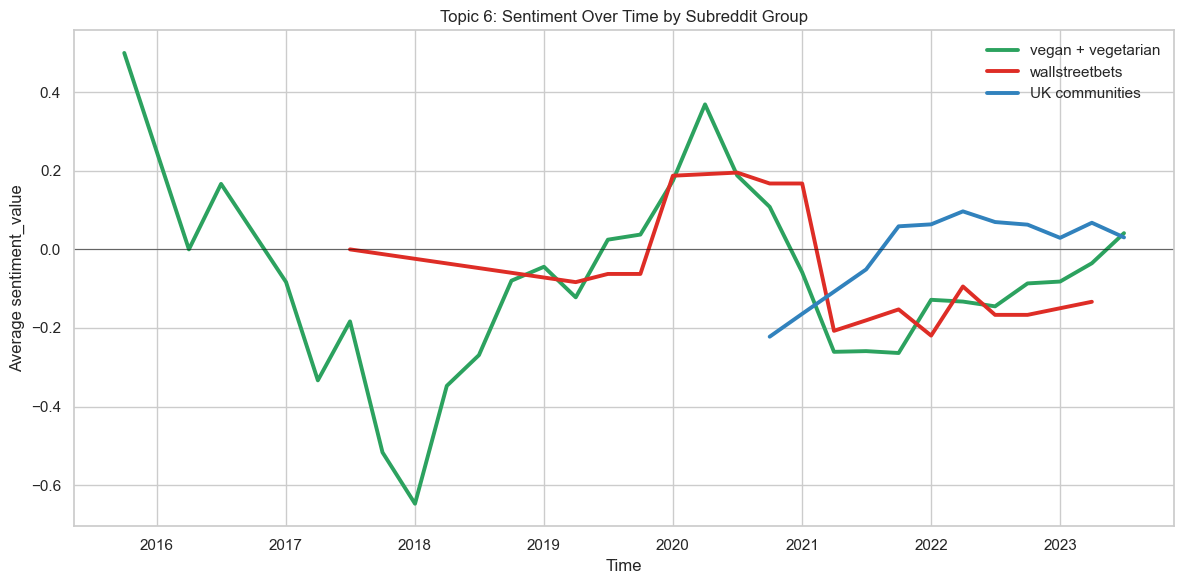

In [9]:
def subreddit_group(subreddit):
    subreddit = str(subreddit).lower().strip()
    if subreddit in {"vegan", "vegetarian"}:
        return "vegan + vegetarian"
    if subreddit == "wallstreetbets":
        return "wallstreetbets"
    if subreddit in {"veganuk", "casualuk", "askuk"}:
        return "UK communities"
    return None

topic6["quarter"] = topic6["created_utc"].dt.to_period("Q").dt.to_timestamp()
topic6["subreddit_group"] = topic6["subreddit"].map(subreddit_group)

quarterly = (
    topic6.dropna(subset=["subreddit_group"])
    .groupby(["quarter", "subreddit_group"])
    .agg(mean_sentiment=("sentiment_value", "mean"), n=("sentiment_value", "size"))
    .reset_index()
    .sort_values("quarter")
)
quarterly["sentiment_smooth"] = (
    quarterly.groupby("subreddit_group")["mean_sentiment"]
    .transform(lambda values: values.rolling(4, min_periods=1, center=True).mean())
)

colors = {
    "vegan + vegetarian": "#2ca25f",
    "wallstreetbets": "#de2d26",
    "UK communities": "#3182bd",
}

fig, ax = plt.subplots(figsize=(12, 6))
for group, color in colors.items():
    sub = quarterly[quarterly["subreddit_group"].eq(group)]
    ax.plot(sub["quarter"], sub["sentiment_smooth"], label=group, color=color, linewidth=2.8)
ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_title("Topic 6: Sentiment Over Time by Subreddit Group")
ax.set_xlabel("Time")
ax.set_ylabel("Average sentiment_value")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 3. Statistical results reported in the manuscript

### Sentiment and engagement within Topic 6

In [10]:
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm

engagement_pair = topic6[["score", "sentiment_value"]].dropna()
pearson_engagement = pearsonr(engagement_pair["sentiment_value"], engagement_pair["score"])
spearman_engagement = spearmanr(engagement_pair["sentiment_value"], engagement_pair["score"])

# Subreddit fixed effects are absorbed by within-subreddit demeaning.
fe_data = topic6[["score", "sentiment_value", "subreddit"]].dropna().copy()
grouped = fe_data.groupby("subreddit")
fe_data["score_within"] = fe_data["score"] - grouped["score"].transform("mean")
fe_data["sentiment_within"] = fe_data["sentiment_value"] - grouped["sentiment_value"].transform("mean")
fe_data = fe_data[grouped["sentiment_value"].transform("nunique").gt(1)].copy()

fe_model = sm.OLS(fe_data["score_within"], fe_data[["sentiment_within"]]).fit(
    cov_type="cluster", cov_kwds={"groups": fe_data["subreddit"]}
)
fe_ci = fe_model.conf_int().loc["sentiment_within"]

engagement_results = pd.DataFrame([
    {
        "analysis": "Pearson correlation",
        "estimate": pearson_engagement.statistic,
        "ci_low": np.nan,
        "ci_high": np.nan,
        "p_value": pearson_engagement.pvalue,
        "n": len(engagement_pair),
    },
    {
        "analysis": "Spearman correlation",
        "estimate": spearman_engagement.statistic,
        "ci_low": np.nan,
        "ci_high": np.nan,
        "p_value": spearman_engagement.pvalue,
        "n": len(engagement_pair),
    },
    {
        "analysis": "Subreddit fixed effects; clustered SE",
        "estimate": fe_model.params["sentiment_within"],
        "ci_low": fe_ci.iloc[0],
        "ci_high": fe_ci.iloc[1],
        "p_value": fe_model.pvalues["sentiment_within"],
        "n": int(fe_model.nobs),
    },
])
display(engagement_results.style.format({
    "estimate": "{:.3f}", "ci_low": "{:.3f}", "ci_high": "{:.3f}", "p_value": "{:.3f}",
}))

,analysis,estimate,ci_low,ci_high,p_value,n
0,Pearson correlation,-0.009,nan,nan,0.518,4930
1,Spearman correlation,0.010,nan,nan,0.498,4930
2,Subreddit fixed effects; clustered SE,-0.247,-6.327,5.834,0.937,4399


### Subreddit sentiment comparison

In [11]:
reported_subreddits = ["askuk", "casualuk", "vegan", "wallstreetbets"]
subreddit_sentiment = (
    topic6[topic6["subreddit"].isin(reported_subreddits)]
    .groupby("subreddit")
    .agg(
        n=("sentiment_value", "size"),
        mean_sentiment=("sentiment_value", "mean"),
        median_sentiment=("sentiment_value", "median"),
    )
    .sort_values("mean_sentiment", ascending=False)
)
display(subreddit_sentiment.style.format({"mean_sentiment": "{:.3f}", "median_sentiment": "{:.1f}"}))

,n,mean_sentiment,median_sentiment
subreddit,,,
askuk,236,0.140,0.0
casualuk,190,0.111,0.0
wallstreetbets,229,-0.175,0.0
vegan,843,-0.225,0.0


### Topic 6 temporal composition and spatial change

In [12]:
pre_announcement = topic6["created_utc"].lt(MCPLANT_ANNOUNCEMENT)

yearly_topic6 = (
    topic6.groupby("year")
    .agg(
        observations=("id", "size"),
        mcplant_references=("mcplant_product_reference", "sum"),
        mean_sentiment=("sentiment_value", "mean"),
        mean_umap_x=("umap2_x", "mean"),
        mean_umap_y=("umap2_y", "mean"),
    )
    .reset_index()
)
yearly_topic6["mcplant_reference_share"] = (
    yearly_topic6["mcplant_references"] / yearly_topic6["observations"]
)

reported_years = yearly_topic6[yearly_topic6["year"].between(2020, 2023)]
display(reported_years[["year", "observations", "mcplant_references", "mcplant_reference_share"]].style.format({
    "mcplant_reference_share": "{:.1%}",
}))

spatial = topic6[["year", "sentiment_value", "umap2_x", "umap2_y"]].dropna()
temporal_tests = []
for outcome, label in [
    ("sentiment_value", "Year × sentiment"),
    ("umap2_x", "Year × UMAP-X"),
    ("umap2_y", "Year × UMAP-Y"),
]:
    result = spearmanr(spatial["year"], spatial[outcome])
    temporal_tests.append({"analysis": label, "spearman_rho": result.statistic, "p_value": result.pvalue})

for coordinate, label in [("umap2_x", "Sentiment × UMAP-X"), ("umap2_y", "Sentiment × UMAP-Y")]:
    result = spearmanr(spatial["sentiment_value"], spatial[coordinate])
    temporal_tests.append({"analysis": label, "spearman_rho": result.statistic, "p_value": result.pvalue})

temporal_tests = pd.DataFrame(temporal_tests)
display(temporal_tests.style.format({"spearman_rho": "{:.3f}", "p_value": "{:.4g}"}))

display(Markdown(
    f"Topic 6 contains **{len(topic6):,} observations**. "
    f"**{pre_announcement.sum():,} ({pre_announcement.mean():.1%})** predate the McPlant announcement."
))

,year,observations,mcplant_references,mcplant_reference_share
8,2020,876,582,66.4%
9,2021,820,556,67.8%
10,2022,1989,1613,81.1%
11,2023,752,631,83.9%


,analysis,spearman_rho,p_value
0,Year × sentiment,0.069,1.291e-06
1,Year × UMAP-X,0.164,6.142e-31
2,Year × UMAP-Y,-0.171,1.233e-33
3,Sentiment × UMAP-X,0.089,3.613e-10
4,Sentiment × UMAP-Y,-0.008,0.5593


Topic 6 contains **4,930 observations**. **616 (12.5%)** predate the McPlant announcement.

## 4. Validation analyses requested during review

### Sentiment model output

In [13]:
sentiment_diagnostic = (
    df.groupby("sentiment_value")
    .agg(
        observations=("id", "size"),
        mean_confidence=("sentiment_confidence", "mean"),
        median_confidence=("sentiment_confidence", "median"),
    )
    .reindex([-1, 0, 1])
)
sentiment_diagnostic["share"] = sentiment_diagnostic["observations"] / len(df)
display(sentiment_diagnostic.style.format({
    "mean_confidence": "{:.3f}", "median_confidence": "{:.3f}", "share": "{:.1%}",
}))

,observations,mean_confidence,median_confidence,share
sentiment_value,,,,
-1,95810,0.722,0.735,34.2%
0,100801,0.653,0.639,36.0%
1,83285,0.803,0.858,29.8%


### UMAP stability across seeds and settings

In [14]:
from scipy.spatial import procrustes
from sklearn.manifold import trustworthiness
from sklearn.neighbors import NearestNeighbors
from umap import UMAP

stability_embeddings = df["stability_embedding"].dropna()
stability_X = np.vstack(stability_embeddings.tolist()).astype("float32")
print("UMAP stability sample:", len(stability_X), "observations")

variants = [
    {"name": "baseline seed 42", "n_neighbors": 30, "min_dist": 0.05, "random_state": 42},
    {"name": "seed 17", "n_neighbors": 30, "min_dist": 0.05, "random_state": 17},
    {"name": "seed 73", "n_neighbors": 30, "min_dist": 0.05, "random_state": 73},
    {"name": "neighbors 15", "n_neighbors": 15, "min_dist": 0.05, "random_state": 42},
    {"name": "neighbors 60", "n_neighbors": 60, "min_dist": 0.05, "random_state": 42},
    {"name": "min_dist 0.20", "n_neighbors": 30, "min_dist": 0.20, "random_state": 42},
]

high_neighbors = (
    NearestNeighbors(n_neighbors=16, metric="cosine")
    .fit(stability_X).kneighbors(return_distance=False)[:, 1:]
)

stability_rows = []
baseline_coordinates = None
baseline_neighbors = None

for variant in variants:
    coordinates = UMAP(
        n_components=2,
        n_neighbors=variant["n_neighbors"],
        min_dist=variant["min_dist"],
        metric="cosine",
        random_state=variant["random_state"],
        low_memory=True,
    ).fit_transform(stability_X)

    low_neighbors = (
        NearestNeighbors(n_neighbors=16)
        .fit(coordinates).kneighbors(return_distance=False)[:, 1:]
    )
    high_overlap = np.mean([
        len(set(high).intersection(low)) / 15
        for high, low in zip(high_neighbors, low_neighbors)
    ])

    if baseline_coordinates is None:
        baseline_coordinates = coordinates
        baseline_neighbors = low_neighbors
        baseline_overlap = 1.0
        disparity = 0.0
    else:
        baseline_overlap = np.mean([
            len(set(base).intersection(low)) / 15
            for base, low in zip(baseline_neighbors, low_neighbors)
        ])
        _, _, disparity = procrustes(baseline_coordinates, coordinates)

    stability_rows.append({
        "specification": variant["name"],
        "trustworthiness_k15": trustworthiness(
            stability_X, coordinates, n_neighbors=15, metric="cosine"
        ),
        "high_dimensional_neighbor_retention": high_overlap,
        "neighbor_overlap_with_baseline": baseline_overlap,
        "procrustes_disparity": disparity,
    })

umap_stability = pd.DataFrame(stability_rows)
display(umap_stability.style.format({
    "trustworthiness_k15": "{:.3f}",
    "high_dimensional_neighbor_retention": "{:.3f}",
    "neighbor_overlap_with_baseline": "{:.3f}",
    "procrustes_disparity": "{:.3f}",
}))

UMAP stability sample: 3000 observations


,specification,trustworthiness_k15,high_dimensional_neighbor_retention,neighbor_overlap_with_baseline,procrustes_disparity
0,baseline seed 42,0.839,0.155,1.000,0.000
1,seed 17,0.836,0.154,0.451,0.031
2,seed 73,0.840,0.155,0.454,0.036
3,neighbors 15,0.847,0.172,0.375,0.061
4,neighbors 60,0.831,0.141,0.389,0.043
5,min_dist 0.20,0.816,0.134,0.525,0.034


### LLM sampling, prompt, and label stability

In [15]:
# The manuscript interpretation used the 100 posts closest to the Topic 6 centroid.
llm_sample = topic6.nsmallest(100, "distance_to_centroid").copy()

def format_posts(sample, max_chars=500):
    formatted = []
    for number, (_, row) in enumerate(sample.iterrows(), 1):
        text = re.sub(r"\s+", " ", str(row["body"])).strip()[:max_chars]
        formatted.append(
            f"POST {number}\nDate: {row['created_utc']}\n"
            f"Subreddit: {row['subreddit']}\nText: {text}"
        )
    return "\n\n".join(formatted)

SYSTEM_PROMPT = """You are assisting an academic researcher in interpreting one semantic region.
Use only the supplied posts. Do not overgeneralize beyond them. Do not infer why the region is
distant from other regions because no comparison posts are supplied. Return valid JSON with keys:
label, summary, themes. The label must be at most 12 words and themes must contain 3 to 5 strings."""

USER_PROMPT = f"""Interpret Topic {TOPIC_ID} from these representative observations.
Describe what the supplied posts appear to be about and distinguish earlier discussion from
post-2020 McPlant discussion when the sample supports that distinction.

{format_posts(llm_sample)}"""

print("Representative observations supplied to each LLM run:", len(llm_sample))

Representative observations supplied to each LLM run: 100


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

LLM_MODELS = ["llama3.1:8b", "mistral:7b"]
LLM_SEEDS = [11, 22, 33]

def parse_json_response(text):
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", text, flags=re.DOTALL)
        return json.loads(match.group(0)) if match else {
            "label": text, "summary": "", "themes": []
        }

if RERUN_LLM_STABILITY:
    import ollama

    llm_rows = []
    for model_name in LLM_MODELS:
        for seed in LLM_SEEDS:
            response = ollama.chat(
                model=model_name,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": USER_PROMPT},
                ],
                format="json",
                options={
                    "temperature": 0.1,
                    "seed": seed,
                    "num_predict": 350,
                    "num_ctx": 16384,
                },
            )
            parsed = parse_json_response(response["message"]["content"])
            llm_rows.append({
                "model": model_name,
                "seed": seed,
                "label": parsed.get("label", ""),
                "summary": parsed.get("summary", ""),
                "themes": json.dumps(parsed.get("themes", []), ensure_ascii=False),
            })
    llm_results = pd.DataFrame(llm_rows)
else:
    cached_runs = parquet_metadata[b"llm_stability_runs"].decode("utf-8")
    llm_results = pd.DataFrame(json.loads(cached_runs))

display(llm_results[["model", "seed", "label", "themes"]])

normalized_labels = (
    llm_results["label"].str.lower()
    .str.replace(r"[^a-z0-9]+", " ", regex=True).str.strip()
)
modal_label_share = normalized_labels.value_counts(normalize=True).iloc[0]

comparison_text = llm_results["label"] + " " + llm_results["themes"]
matrix = TfidfVectorizer(
    ngram_range=(1, 2), stop_words="english"
).fit_transform(comparison_text)
similarity = cosine_similarity(matrix)

within_model = []
across_models = []
for i in range(len(llm_results)):
    for j in range(i + 1, len(llm_results)):
        target = (
            within_model
            if llm_results.iloc[i]["model"] == llm_results.iloc[j]["model"]
            else across_models
        )
        target.append(similarity[i, j])

llm_stability = pd.DataFrame([
    {"measure": "modal exact-label share", "value": modal_label_share},
    {"measure": "mean label/theme similarity within model", "value": np.mean(within_model)},
    {"measure": "mean label/theme similarity across models", "value": np.mean(across_models)},
])
display(llm_stability.style.format({"value": "{:.3f}"}))

,model,seed,label,themes
0,llama3.1:8b,11,McDonald's McPlant Discussion,"[""McDonald's"", ""McPlant"", ""plant-based"", ""vega..."
1,llama3.1:8b,22,McDonald's McPlant Discussion,"[""McDonald's"", ""McPlant"", ""plant-based"", ""vega..."
2,llama3.1:8b,33,McDonald's McPlant Discussion,"[""McDonald's"", ""McPlant"", ""plant-based"", ""vega..."
3,mistral:7b,11,McDonald's McPlant Discussion,"[""McDonald's"", ""plant-based food"", ""vegan opti..."
4,mistral:7b,22,McDonald's McPlant Discussion,"[""McDonald's"", ""McPlant"", ""Beyond Meat"", ""Vega..."
5,mistral:7b,33,McDonald's McPlant Discussion,"[""McDonald's McPlant"", ""Beyond Meat"", ""Vegan F..."


,measure,value
0,modal exact-label share,1.000
1,mean label/theme similarity within model,0.679
2,mean label/theme similarity across models,0.493


## 5. Results reproduced

In [17]:
year_shares = reported_years.set_index("year")["mcplant_reference_share"]
time_sentiment = temporal_tests.loc[
    temporal_tests["analysis"].eq("Year × sentiment")
].iloc[0]

display(Markdown(
    f"- Topic 6 contains **{len(topic6):,} observations**; "
    f"**{pre_announcement.sum():,} ({pre_announcement.mean():.1%})** predate the McPlant announcement.\n"
    f"- McPlant references account for **{year_shares.loc[2020]:.1%}** of Topic 6 in 2020, "
    f"**{year_shares.loc[2021]:.1%}** in 2021, **{year_shares.loc[2022]:.1%}** in 2022, "
    f"and **{year_shares.loc[2023]:.1%}** in 2023.\n"
    f"- Sentiment and raw Reddit score are unrelated: Pearson **r={pearson_engagement.statistic:.3f}** "
    f"(p={pearson_engagement.pvalue:.3f}) and Spearman **ρ={spearman_engagement.statistic:.3f}** "
    f"(p={spearman_engagement.pvalue:.3f}).\n"
    f"- The subreddit fixed-effects estimate is **b={fe_model.params['sentiment_within']:.3f}**, "
    f"95% CI [{fe_ci.iloc[0]:.3f}, {fe_ci.iloc[1]:.3f}], p={fe_model.pvalues['sentiment_within']:.3f}.\n"
    f"- Sentiment becomes modestly more positive over time: Spearman **ρ={time_sentiment['spearman_rho']:.3f}**, "
    f"p={time_sentiment['p_value']:.4g}."
))

- Topic 6 contains **4,930 observations**; **616 (12.5%)** predate the McPlant announcement.
- McPlant references account for **66.4%** of Topic 6 in 2020, **67.8%** in 2021, **81.1%** in 2022, and **83.9%** in 2023.
- Sentiment and raw Reddit score are unrelated: Pearson **r=-0.009** (p=0.518) and Spearman **ρ=0.010** (p=0.498).
- The subreddit fixed-effects estimate is **b=-0.247**, 95% CI [-6.327, 5.834], p=0.937.
- Sentiment becomes modestly more positive over time: Spearman **ρ=0.069**, p=1.291e-06.